# 2. Análisis de ratios y modelos de probabilidad de incumplimiento

**Proyecto:** Análisis de probabilidad de incumplimiento de emisores colombianos de energía — ISA,
ISAGEN, EPM, CELSIA y Enel Colombia.

Este notebook parte de `data_xbrl_out/ratios_xbrl.csv` (generado en `01_extraccion_datos.ipynb` a
partir de los 146 archivos XBRL descargados del RNVE) — no vuelve a tocar los archivos fuente, así
que corre en segundos.

## Qué hace este notebook

1. Evolución histórica de los ratios de endeudamiento, cobertura, liquidez y rentabilidad
2. Modelo contable — Z''-Score (Altman, mercados emergentes) para los 5 emisores
3. Modelo de mercado — Distancia a Default (Merton/KMV) para ISA y CELSIA
4. Comparación entre ambos modelos y conclusiones

In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm
from scipy.optimize import fsolve

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

df = pd.read_csv("../data_xbrl_out/ratios_xbrl.csv")
df["fecha"] = pd.PeriodIndex(df["año"].astype(str) + "Q" + df["trimestre"].astype(str), freq="Q").to_timestamp(how="end")
df = df.sort_values(["empresa", "fecha"]).reset_index(drop=True)

EMPRESAS = ["ISA", "ISAGEN", "EPM", "CELSIA", "ENEL"]
COLORES = {"ISA": "#1f77b4", "ISAGEN": "#ff7f0e", "EPM": "#2ca02c", "CELSIA": "#d62728", "ENEL": "#9467bd"}

df.head()

,empresa,año,trimestre,archivo,escala_detectada,efectivo,activo_corriente,activo_total,pasivo_corriente,pasivo_no_corriente,pasivo_total,patrimonio_total,ganancias_retenidas,inventarios,deuda_cp,...,ffo_intereses,ffo_deuda,razon_corriente,prueba_acida,caja_activos,caja_deuda_cp,margen_ebitda,margen_neto,zscore_x1,zscore_x2,zscore_x3,zscore_x4,zscore,zscore_zona,fecha
0,CELSIA,2020,1,Q1 2020.xbrl,0.001,502916.479,2031292.006,1.225894e+07,2281054.158,4315362.613,6596416.771,5662526.203,323020.110,221393.090,836886.912,...,NaN,NaN,0.890506,0.793448,0.041024,0.600937,NaN,NaN,-0.020374,0.026350,NaN,0.858425,NaN,NaN,2020-03-31 23:59:59.999999
1,CELSIA,2020,2,Q2 2020.xbrl,0.001,576094.321,2052267.789,1.214731e+07,2067633.516,4422371.541,6490005.057,5657309.932,323020.110,229634.211,819121.849,...,NaN,NaN,0.992568,0.881507,0.047426,0.703307,NaN,NaN,-0.001265,0.026592,NaN,0.871696,NaN,NaN,2020-06-30 23:59:59.999999
2,CELSIA,2020,3,Q3 2020.xbrl,0.001,372786.178,1545443.512,1.213915e+07,1818980.278,4521253.793,6340234.071,5798917.811,323020.110,265853.190,713308.386,...,NaN,NaN,0.849621,0.703466,0.030709,0.522616,NaN,NaN,-0.022533,0.026610,NaN,0.914622,NaN,NaN,2020-09-30 23:59:59.999999
3,CELSIA,2020,4,CIERRE 2020.xbrl,0.001,399547.205,1426594.051,1.181066e+07,2055711.187,4014292.754,6070003.941,5740655.566,323020.110,167135.929,483336.146,...,0.859355,0.078863,0.693966,0.612663,0.033829,0.826645,0.237110,0.068422,-0.053267,0.027350,0.074286,0.945742,4.481959,segura,2020-12-31 23:59:59.999999
4,CELSIA,2021,1,Q1 2021.xbrl,0.001,283111.862,1516662.477,1.227323e+07,2319218.414,4347552.752,6666771.166,5606460.057,289816.424,178356.972,498103.938,...,0.981020,0.076773,0.653954,0.577050,0.023067,0.568379,0.244721,0.077522,-0.065391,0.023614,0.071115,0.840956,4.258914,segura,2021-03-31 23:59:59.999999


## 2.1. Endeudamiento y cobertura

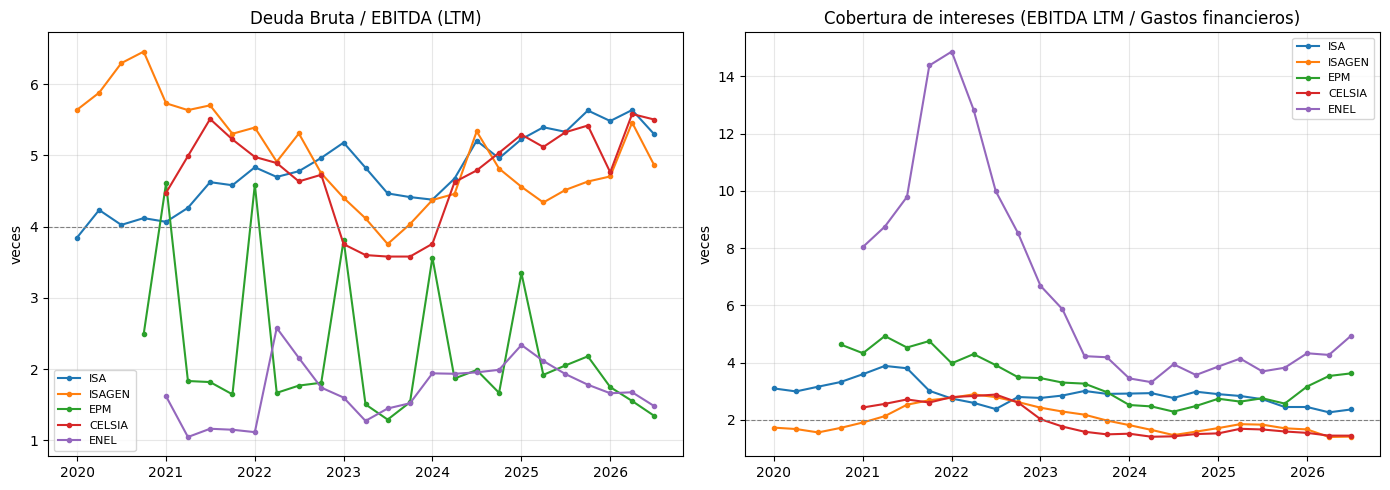

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for empresa in EMPRESAS:
    sub = df[df.empresa == empresa]
    axes[0].plot(sub["fecha"], sub["deuda_bruta_ebitda"], marker="o", markersize=3,
                 label=empresa, color=COLORES[empresa])
    axes[1].plot(sub["fecha"], sub["cobertura_intereses"], marker="o", markersize=3,
                 label=empresa, color=COLORES[empresa])

axes[0].set_title("Deuda Bruta / EBITDA (LTM)")
axes[0].set_ylabel("veces")
axes[0].axhline(4, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_title("Cobertura de intereses (EBITDA LTM / Gastos financieros)")
axes[1].set_ylabel("veces")
axes[1].axhline(2, color="gray", linestyle="--", linewidth=0.8)

for ax in axes:
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Líneas de referencia:** 4.0x en Deuda/EBITDA y 2.0x en cobertura de intereses, umbrales
orientativos típicos de calificadoras para utilities reguladas.

## 2.2. Liquidez

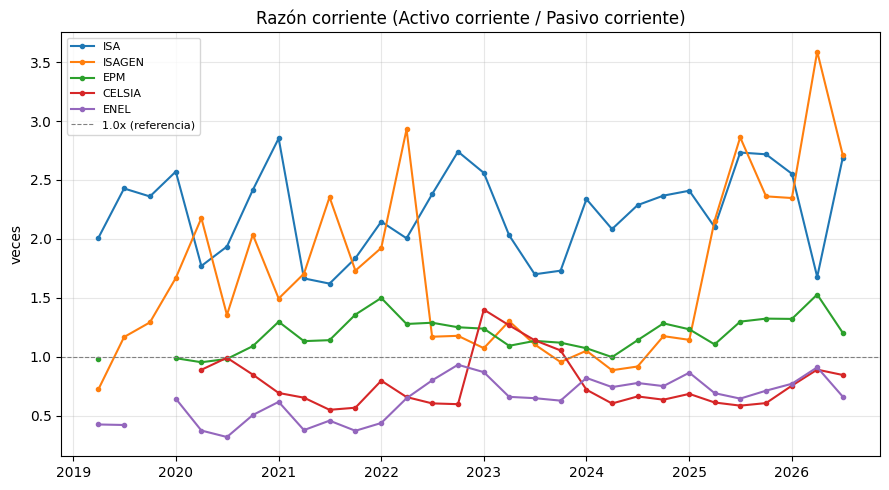

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
for empresa in EMPRESAS:
    sub = df[df.empresa == empresa]
    ax.plot(sub["fecha"], sub["razon_corriente"], marker="o", markersize=3,
            label=empresa, color=COLORES[empresa])

ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="1.0x (referencia)")
ax.set_title("Razón corriente (Activo corriente / Pasivo corriente)")
ax.set_ylabel("veces")
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.3. Rentabilidad / generación de caja

El EBITDA se reconstruye con el método indirecto para las 5 empresas por igual (ver notebook 1 —
en XBRL no existe una etiqueta de EBITDA como tal), y el margen usa `ifrs:Revenue` (ingreso total)
para las 5, incluyendo ISA -sin el ajuste "sin construcción" que sí se usó en la versión con PDF,
porque esa desagregación no existe en los estados financieros formales que se etiquetan en XBRL-.

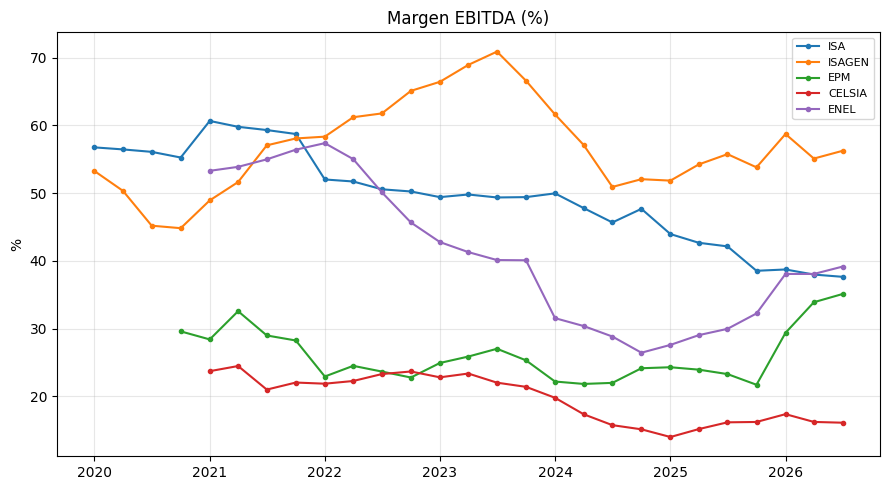

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for empresa in EMPRESAS:
    sub = df[df.empresa == empresa]
    ax.plot(sub["fecha"], sub["margen_ebitda"] * 100, marker="o", markersize=3,
            label=empresa, color=COLORES[empresa])

ax.set_title("Margen EBITDA (%)")
ax.set_ylabel("%")
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.4. Foto más reciente — los 5 emisores lado a lado

In [5]:
ultimo = df.sort_values(["empresa", "fecha"]).groupby("empresa").tail(1)
cols = ["empresa", "año", "trimestre", "deuda_bruta_ebitda", "deuda_neta_ebitda",
        "cobertura_intereses", "razon_corriente", "margen_ebitda", "perfil_vencimientos_cp"]
ultimo[cols].round(2).sort_values("empresa").reset_index(drop=True)

,empresa,año,trimestre,deuda_bruta_ebitda,deuda_neta_ebitda,cobertura_intereses,razon_corriente,margen_ebitda,perfil_vencimientos_cp
0,CELSIA,2026,2,5.50,5.19,1.45,0.85,0.16,0.20
1,ENEL,2026,2,1.48,1.16,4.94,0.66,0.39,0.12
2,EPM,2026,2,1.34,0.98,3.63,1.20,0.35,0.19
3,ISA,2026,2,5.30,4.72,2.37,2.69,0.38,0.03
4,ISAGEN,2026,2,4.86,4.77,1.42,2.71,0.56,0.08


## 2.5. Modelo contable — Z''-Score (Altman, mercados emergentes)

$$Z'' = 3.25 + 6.56X_1 + 3.26X_2 + 6.72X_3 + 1.05X_4$$

| Variable | Definición |
|---|---|
| $X_1$ | (Activo corriente − Pasivo corriente) / Activo total |
| $X_2$ | Ganancias retenidas / Activo total |
| $X_3$ | EBIT / Activo total |
| $X_4$ | Patrimonio / Pasivo total |

**Zonas:** Z'' > 2.6 segura; 1.1–2.6 gris; < 1.1 riesgo.

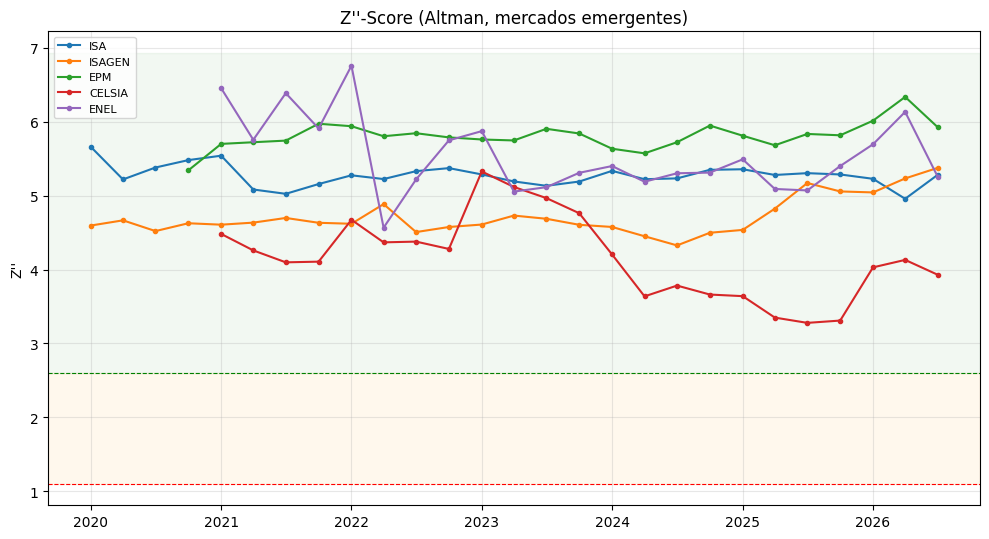

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for empresa in EMPRESAS:
    sub = df[df.empresa == empresa]
    ax.plot(sub["fecha"], sub["zscore"], marker="o", markersize=3,
            label=empresa, color=COLORES[empresa])

ax.axhspan(2.6, ax.get_ylim()[1] if ax.get_ylim()[1] > 2.6 else 10, color="green", alpha=0.05)
ax.axhspan(1.1, 2.6, color="orange", alpha=0.07)
ax.axhline(2.6, color="green", linestyle="--", linewidth=0.8)
ax.axhline(1.1, color="red", linestyle="--", linewidth=0.8)
ax.set_title("Z''-Score (Altman, mercados emergentes)")
ax.set_ylabel("Z''")
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
print("Zona más reciente de cada emisor:\n")
ultimo[["empresa", "año", "trimestre", "zscore", "zscore_zona"]].round(2).sort_values("empresa").reset_index(drop=True)

Zona más reciente de cada emisor:



,empresa,año,trimestre,zscore,zscore_zona
0,CELSIA,2026,2,3.93,segura
1,ENEL,2026,2,5.26,segura
2,EPM,2026,2,5.93,segura
3,ISA,2026,2,5.28,segura
4,ISAGEN,2026,2,5.38,segura


## 2.6. Modelo de mercado — Distancia a Default (Merton / KMV)

Solo ISA y CELSIA tienen equity transado en bolsa. Ver notebook original para el detalle completo
del modelo (sistema de Black-Scholes-Merton, supuestos de acciones en circulación y tasa libre de
riesgo) — aquí se recalcula con el balance actualizado desde XBRL, usando los mismos precios de
ISA y CELSIA ya validados (Investing.com, 2018 en adelante).

In [8]:
def cargar_precios_investing(ruta):
    precios = pd.read_csv(ruta, encoding="utf-8-sig")
    precios["fecha"] = pd.to_datetime(precios["Fecha"], format="%d.%m.%Y")
    precios["precio"] = (precios["Último"].str.replace(".", "", regex=False)
                                            .str.replace(",", ".", regex=False).astype(float))
    precios = precios[["fecha", "precio"]].sort_values("fecha").reset_index(drop=True)
    precios["log_ret"] = np.log(precios["precio"] / precios["precio"].shift(1))
    precios["sigma_e"] = precios["log_ret"].rolling(252).std() * np.sqrt(252)
    return precios

ACCIONES_EN_CIRCULACION = {"ISA": 1_107_677_894, "CELSIA": 1_069_972_554}
TASA_LIBRE_RIESGO = 0.13


def resolver_merton(E, sigma_E, F, r=TASA_LIBRE_RIESGO, T=1.0):
    def ecuaciones(x):
        V, sigma_V = x
        if V <= 0 or sigma_V <= 0:
            return [1e10, 1e10]
        d1 = (np.log(V / F) + (r + 0.5 * sigma_V**2) * T) / (sigma_V * np.sqrt(T))
        d2 = d1 - sigma_V * np.sqrt(T)
        eq1 = V * norm.cdf(d1) - F * np.exp(-r * T) * norm.cdf(d2) - E
        eq2 = norm.cdf(d1) * sigma_V * V - sigma_E * E
        return [eq1, eq2]
    V0, sigma_V0 = E + F, sigma_E * E / (E + F)
    try:
        V, sigma_V = fsolve(ecuaciones, [V0, sigma_V0])
        if V <= 0 or sigma_V <= 0:
            return np.nan, np.nan, np.nan, np.nan
    except Exception:
        return np.nan, np.nan, np.nan, np.nan
    dd = (np.log(V / F) + (r - 0.5 * sigma_V**2) * T) / (sigma_V * np.sqrt(T))
    return V, sigma_V, dd, norm.cdf(-dd)


resultados_merton = []
for empresa, archivo in [("ISA", "isa_investing.csv"), ("CELSIA", "celsia_investing.csv")]:
    precios = cargar_precios_investing(f"../data_precios/{archivo}")
    sub = df[df.empresa == empresa].sort_values("fecha")
    for _, fila in sub.iterrows():
        precio_cercano = precios[precios.fecha <= fila.fecha].tail(1)
        if precio_cercano.empty or pd.isna(precio_cercano.iloc[0]["sigma_e"]):
            continue
        precio = precio_cercano.iloc[0]["precio"]
        sigma_e = precio_cercano.iloc[0]["sigma_e"]
        E = precio * ACCIONES_EN_CIRCULACION[empresa] / 1e6

        if pd.isna(fila["deuda_cp"]) or pd.isna(fila["deuda_lp"]):
            continue
        F = fila["deuda_cp"] + 0.5 * fila["deuda_lp"]
        if F <= 0:
            continue

        V, sigma_V, dd, pd_merton = resolver_merton(E, sigma_e, F)
        resultados_merton.append({"empresa": empresa, "fecha": fila.fecha, "año": fila.año,
                                   "trimestre": fila.trimestre, "distancia_default": dd, "pd_merton": pd_merton})

merton = pd.DataFrame(resultados_merton)
print(f"{len(merton)} trimestres calculados")
merton.tail()

56 trimestres calculados


,empresa,fecha,año,trimestre,distancia_default,pd_merton
51,CELSIA,2025-06-30 23:59:59.999999,2025,2,7.537926,2.387525e-14
52,CELSIA,2025-09-30 23:59:59.999999,2025,3,7.012691,1.168888e-12
53,CELSIA,2025-12-31 23:59:59.999999,2025,4,7.883554,1.590989e-15
54,CELSIA,2026-03-31 23:59:59.999999,2026,1,5.156861,1.255622e-07
55,CELSIA,2026-06-30 23:59:59.999999,2026,2,4.696702,1.321977e-06


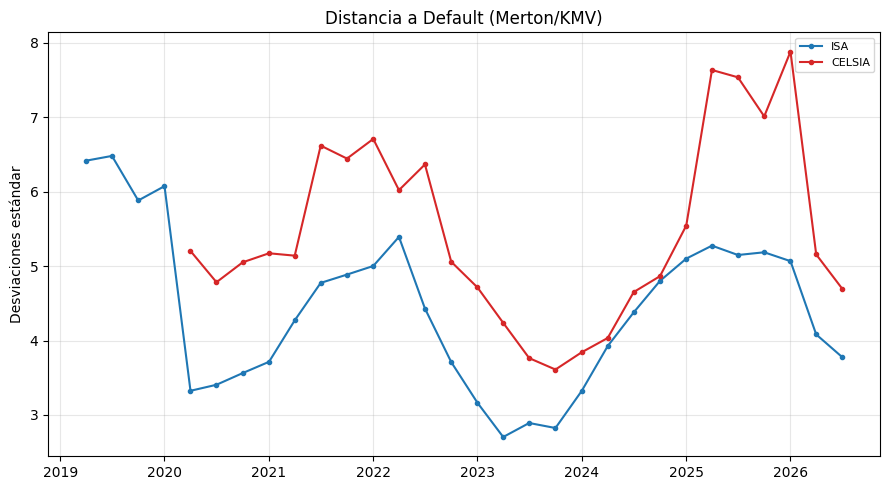

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
for empresa in ["ISA", "CELSIA"]:
    sub = merton[merton.empresa == empresa]
    ax.plot(sub["fecha"], sub["distancia_default"], marker="o", markersize=3,
            label=empresa, color=COLORES[empresa])

ax.set_title("Distancia a Default (Merton/KMV)")
ax.set_ylabel("Desviaciones estándar")
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.7. Conclusiones

- Los 5 emisores se mantienen en zona "segura" de Z''-Score en el trimestre más reciente.
- ISA y CELSIA muestran una Distancia a Default consistentemente alta, coherente con la señal del
  Z''-Score contable para ambas.
- **Diferencia frente a la versión con PDF:** el margen EBITDA de ISA aquí es más bajo (usa ingreso
  total, con construcción, en vez del ajustado "sin construcción"), lo cual es metodológicamente
  correcto dado que esa desagregación no existe en los estados financieros formales -pero significa
  que no es directamente comparable, número a número, contra la versión anterior del proyecto-.
- **Limitaciones:** 4 de 146 trimestres (ENEL 3T2019, EPM 2T2019/3T2019/1T2020) tienen datos
  faltantes porque el archivo descargado del RNVE contiene, por dentro, el período equivocado -un
  problema confirmado de la fuente, no de la extracción-.